In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import stim
import sinter
import matplotlib.pyplot as plt
import os
from qecsim.lattice_surgery.circuit import surgery_circuit
import pickle

'''
Sketches/Notes
'''

# 9 12 15
#---------
# 37 43 49
#---------
# M 3 14 27
# TICK
# CX rec[-1] 6 rec[-1] 7 rec[-1] 8 rec[-2] 6 rec[-2] 7 rec[-2] 8 rec[-3] 6 rec[-3] 7 rec[-3] 8

'\nSketches/Notes\n'

In [ ]:
test_circuit = surgery_circuit(3, target_state_init="X+", control_state_init="X-", noise_depol_data_init = 0.2, noise_measure_flip = 0.2)
test_circuit.diagram("timeslice-svg")

TypeError: can only concatenate list (not "int") to list

In [4]:
'''
Define Test which checks the x basis measurement of the target
-> Should expect an always +1 measurement as c = 1, t = 0 -> c = 1, t = 1 

Just testing for d = 3 rund therefore some fixed values as qubit index
'''

def logical_x_mean_value(test_circuit : stim.Circuit, shot : int):

    #Define sampler and run samples
    sampler = test_circuit.compile_sampler()
    result = sampler.sample(shots = shot)

    logical_x_all_shots : list[list] = []

    for i in range(shot):
        logical_x_all_shots.append([result[i,-2], result[i,-5], result[i,-8]])

    # List where each resulting parity of each run is saved
    all_sums = []

    for i in range(shot):

        #Translating measurement values into int
        for elements in logical_x_all_shots[i]:
            joint_measurement = []
            if elements == False:
                joint_measurement.append(1)
            elif elements == True:
                joint_measurement.append(-1)

        #Current parity of given shot
        current_sums = 1

        for i in joint_measurement:
            current_sums = current_sums * i

        all_sums.append(current_sums)

    #Count the different results:
    count_off = 0
    count_on = 0

    for results in all_sums:
        if results == 1:
            count_off +=1
        elif results == -1:
            count_on +=1

    return(count_off / shot, count_on / shot)

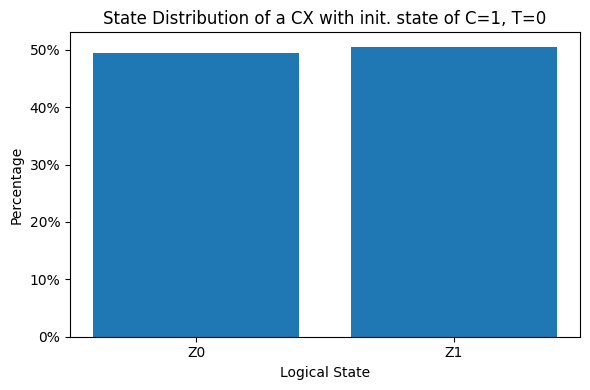

In [24]:
x_values = ["Z0", "Z1"]
y_values = logical_x_mean_value(test_circuit, 1000)

# Create the plot
plt.figure(figsize=(6, 4))
plt.bar(x_values, y_values)

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Labels and title
plt.xlabel('Logical State')
plt.ylabel('Percentage')
plt.title('State Distribution of a CX with init. state of C=1, T=0')

plt.tight_layout()
plt.show()

In [7]:
task_noisy = [sinter.Task(
    circuit = surgery_circuit(
        distance = d,
        control_state_init = c_state,
        target_state_init = t_state,
        noise_depol_data_init = 0.0,
        noise_measure_flip = noise
    ),
    json_metadata={'p': noise, 'distance' : d, 'state_control' : c_state, 'state_target' : t_state}
    ) 
    for noise in [0.010, 0.015, 0.1, 0.125, 0.2, 0.3, 0.35, 0.4, 0.45]
    for d in [3,5,7]
    for c_state in {"Z1"}
    for t_state in {"Z0"}
    ]

stats_noisy : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=1000,
    print_progress=True
)

Starting 8 workers...
27 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                                      
        1 pymatching <1m     997679        1000 p=0.01,distance=3,state_control=Z1,state_target=Z0 
        1 pymatching   ?    1000000        1000 p=0.01,distance=5,state_control=Z1,state_target=Z0 
        1 pymatching   ?    1000000        1000 p=0.01,distance=7,state_control=Z1,state_target=Z0 
        1 pymatching   ?    1000000        1000 p=0.015,distance=3,state_control=Z1,state_target=Z0
        1 pymatching   ?    1000000        1000 p=0.015,distance=5,state_control=Z1,state_target=Z0
        1 pymatching   ?    1000000        1000 p=0.015,distance=7,state_control=Z1,state_target=Z0
        1 pymatching   ?    1000000        1000 p=0.1,distance=3,state_control=Z1,state_target=Z0  
        1 pymatching   ?    1000000        1000 p=0.1,distance=5,state_control=Z1,state_target=Z0  
        0 pymatching ?·∞    1000000        1000 p=0.1,distance=

In [11]:
#Dumping Stats with pickle:
with open("lattice_surgery_measurement_noise.pkl", "wb") as file:
    pickle.dump(stats_noisy, file)

In [ ]:
#Loading Stats with pickle
with open("lattice_surgery_measurement_noise.pkl", "rb") as file:
    complete_stats = pickle.load(file)

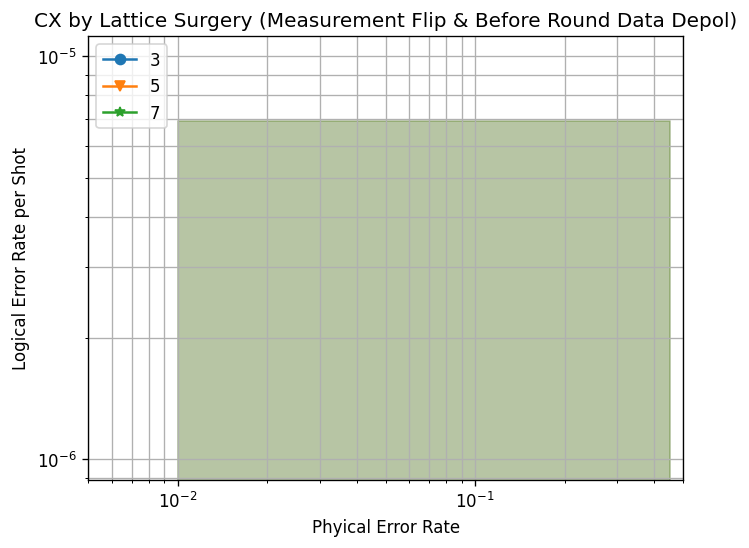

In [15]:
fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance']
)
ax.loglog()
ax.set_xlim(5e-3, 0.5)
ax.set_title("CX by Lattice Surgery (Measurement Flip & Before Round Data Depol)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger